Computing sigmas for all 4096 kernels...
Done.

Vulnerability Threshold Justification

  VP Wavelet sigma = 1.11e-16
  Note: VP wavelet sigma is effectively 0 by construction.
  It serves as a topological (ECC) reference only.
  The Robust threshold is anchored by Kernel 3503 (sigma=0.9786),
  which retains >74% of its margin under the full epsilon sweep.

  Threshold Band Justification Table
  ----------------------------------------------------------------------
  Band         Range                 Count      %  Rationale
  ----------------------------------------------------------------------
  Critical     [0.000, 0.001)          151   3.7%  fails under infinitesimal perturbation
  High Risk    [0.001, 0.005)          589  14.4%  fails within standard FGSM threat model (eps=0.001-0.005)
  Moderate     [0.005, 0.050)         2314  56.5%  vulnerable to domain shift
  Robust       >= 0.050               1042  25.4%  retains margin across full tested threat model (eps<=0.5)
  ---------

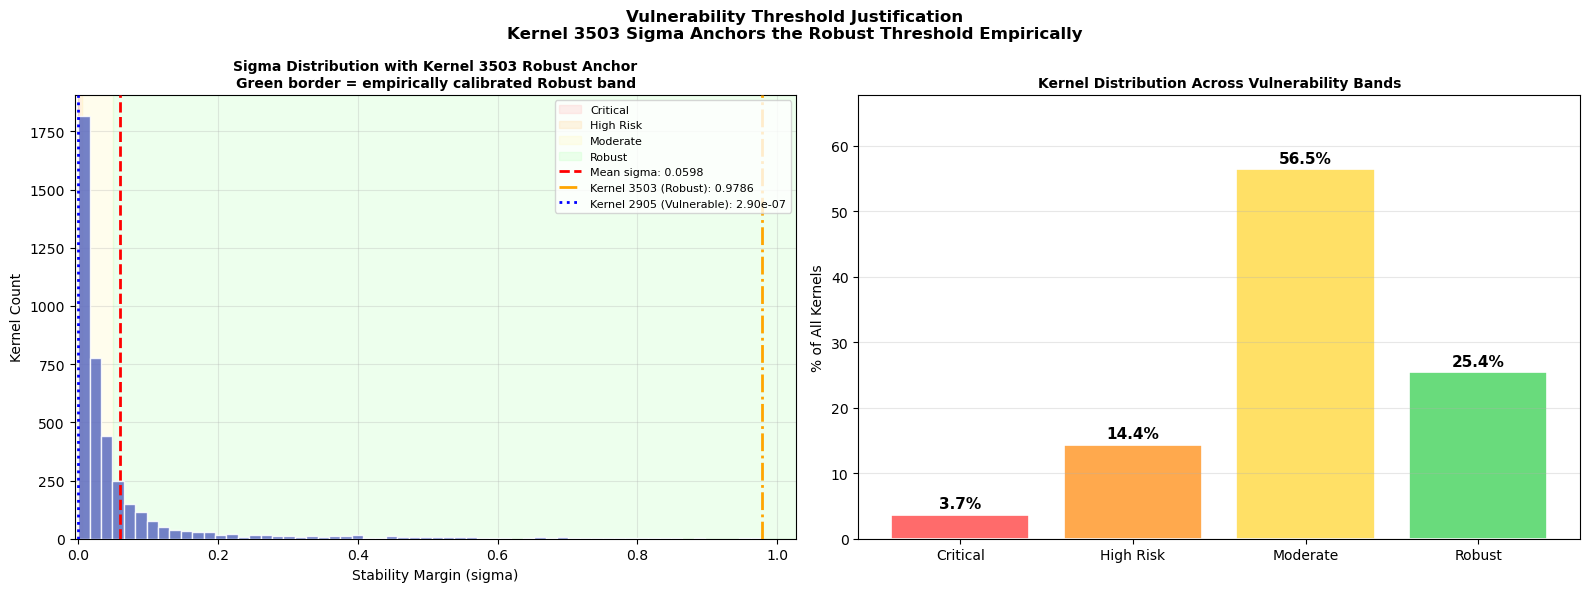

Saved: ThresholdJustification.png


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sharedfunctions import (loadKernels, computeSigma, computeMagnitudeResponse,
                              generateVPWaveletKernel,
                              IDXROBUST, IDXVULNERABLE, CSVPATH)

# ============================================================
# Load kernels and compute sigmas
# ============================================================
kernels = loadKernels(CSVPATH)

print("Computing sigmas for all 4096 kernels...")
sigmas = np.array([computeSigma(h) for h in kernels])
meanSigma = np.mean(sigmas)
print("Done.")

# ============================================================
# VP Wavelet — used for ECC reference only, not sigma anchor
# ============================================================
# NOTE: The VP wavelet has sigma=0 by construction (rank-1 kernel,
# zero variety intersects T^2). It is retained as a topological
# reference for ECC distance computation only. The Robust threshold
# sigma >= 0.05 is anchored empirically by the adversarial perturbation
# results in Section 4.5, not by the VP wavelet sigma.
vp = generateVPWaveletKernel()
sigmaVp = computeSigma(vp)
sigmaRobustAnchor = sigmas[IDXROBUST]

# ============================================================
# Print threshold justification table
# ============================================================
print("\n" + "="*60)
print("Vulnerability Threshold Justification")
print("="*60)

print(f"\n  VP Wavelet sigma = {sigmaVp:.2e}")
print(f"  Note: VP wavelet sigma is effectively 0 by construction.")
print(f"  It serves as a topological (ECC) reference only.")
print(f"  The Robust threshold is anchored by Kernel {IDXROBUST} "
      f"(sigma={sigmaRobustAnchor:.4f}),")
print(f"  which retains >74% of its margin under the full epsilon sweep.\n")

thresholds = {
    "Critical":  (0.000, 0.001),
    "High Risk": (0.001, 0.005),
    "Moderate":  (0.005, 0.050),
    "Robust":    (0.050, np.inf),
}

rationales = {
    "Critical":  "fails under infinitesimal perturbation",
    "High Risk": "fails within standard FGSM threat model (eps=0.001-0.005)",
    "Moderate":  "vulnerable to domain shift",
    "Robust":    "retains margin across full tested threat model (eps<=0.5)",
}

print("  Threshold Band Justification Table")
print("  " + "-"*70)
print(f"  {'Band':<12} {'Range':<20} {'Count':>6} {'%':>6}  {'Rationale'}")
print("  " + "-"*70)

for band, (lo, hi) in thresholds.items():
    if hi == np.inf:
        mask = sigmas >= lo
        rangeStr = f">= {lo:.3f}"
    else:
        mask = (sigmas >= lo) & (sigmas < hi)
        rangeStr = f"[{lo:.3f}, {hi:.3f})"
    count = mask.sum()
    pct = 100 * count / len(sigmas)
    print(f"  {band:<12} {rangeStr:<20} {count:>6} {pct:>5.1f}%  {rationales[band]}")

print("  " + "-"*70)

print(f"\n  Robust threshold anchor:")
print(f"    Kernel {IDXROBUST} sigma = {sigmas[IDXROBUST]:.6f}")
print(f"    Kernel {IDXVULNERABLE} sigma = {sigmas[IDXVULNERABLE]:.2e}")
print(f"\n  Threshold sensitivity check:")
for delta in [-0.5, 0.5]:
    adj = 0.05 * (1 + delta)
    rob = 100 * (sigmas >= adj).mean()
    crit_hr = 100 * (sigmas < 0.005).mean()
    print(f"    Robust threshold at {adj:.3f}: {rob:.1f}% robust  "
          f"(Critical+HighRisk unchanged at {crit_hr:.1f}%)")

# ============================================================
# Figure
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    f"Vulnerability Threshold Justification\n"
    f"Kernel {IDXROBUST} Sigma Anchors the Robust Threshold Empirically",
    fontsize=12, fontweight='bold'
)

# Left panel: histogram with band shading
ax = axes[0]
colorsBand = {
    "Critical":  ("#ffcccc", 0.000, 0.001),
    "High Risk": ("#ffe0b3", 0.001, 0.005),
    "Moderate":  ("#fffacc", 0.005, 0.050),
    "Robust":    ("#ccffcc", 0.050, max(sigmas.max(), 0.05) * 1.1),
}
for label, (color, lo, hi) in colorsBand.items():
    ax.axvspan(lo, hi, alpha=0.35, color=color, label=label)

ax.hist(sigmas, bins=60, color='#5c6bc0', edgecolor='white', alpha=0.85, zorder=3)
ax.axvline(meanSigma, color='red', linewidth=2, linestyle='--',
           label=f'Mean sigma: {meanSigma:.4f}', zorder=4)
ax.axvline(sigmas[IDXROBUST], color='orange', linewidth=2, linestyle='-.',
           label=f'Kernel {IDXROBUST} (Robust): {sigmas[IDXROBUST]:.4f}', zorder=4)
ax.axvline(sigmas[IDXVULNERABLE], color='blue', linewidth=2, linestyle=':',
           label=f'Kernel {IDXVULNERABLE} (Vulnerable): {sigmas[IDXVULNERABLE]:.2e}',
           zorder=4)
ax.set_title(f"Sigma Distribution with Kernel {IDXROBUST} Robust Anchor\n"
             "Green border = empirically calibrated Robust band",
             fontsize=10, fontweight='bold')
ax.set_xlabel("Stability Margin (sigma)", fontsize=10)
ax.set_ylabel("Kernel Count", fontsize=10)
ax.set_xlim(-0.005, min(sigmas.max() * 1.05, 1.1))
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3, zorder=0)

# Right panel: band percentage bar chart
ax2 = axes[1]
bandNames  = list(thresholds.keys())
bandColors = ['#ff6b6b', '#ffa94d', '#ffe066', '#69db7c']
bandCounts = []
for band, (lo, hi) in thresholds.items():
    if hi == np.inf:
        bandCounts.append(100 * (sigmas >= lo).mean())
    else:
        bandCounts.append(100 * ((sigmas >= lo) & (sigmas < hi)).mean())

bars = ax2.bar(bandNames, bandCounts, color=bandColors,
               edgecolor='white', linewidth=1.2)
for bar, pct in zip(bars, bandCounts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{pct:.1f}%', ha='center', va='bottom',
             fontsize=11, fontweight='bold')

ax2.set_title("Kernel Distribution Across Vulnerability Bands",
              fontsize=10, fontweight='bold')
ax2.set_ylabel("% of All Kernels", fontsize=10)
ax2.set_ylim(0, max(bandCounts) * 1.2)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("ThresholdJustification.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ThresholdJustification.png")